In [2]:
!pip install -q pandas numpy scikit-learn networkx matplotlib requests

In [4]:
import os
import requests
import pandas as pd

# Verified official URL for CTU-13 Scenario 1 (Neris Botnet capture)
url = "https://mcfp.felk.cvut.cz/publicDatasets/CTU-Malware-Capture-Botnet-42/detailed-bidirectional-flow-labels/capture20110810.binetflow"
filename = "ctu13_scenario1.binetflow"

# Stream only the required head lines to avoid downloading multi-gigabyte archives
nrows_to_fetch = 50000

if not os.path.exists(filename):
    print(f"[*] Streaming first {nrows_to_fetch} rows of real CTU-13 NetFlow data...")
    headers = {"User-Agent": "Mozilla/5.0"}
    with requests.get(url, headers=headers, stream=True, timeout=30) as r:
        r.raise_for_status()
        with open(filename, "wb") as f:
            line_count = 0
            for line in r.iter_lines():
                if line:
                    f.write(line + b"\n")
                    line_count += 1
                    if line_count >= nrows_to_fetch:
                        break
    print(f"[+] Download complete: Saved {line_count} rows to {filename}")

# Ingest into Pandas DataFrame
print("[*] Ingesting real network flows into memory...")
df_real = pd.read_csv(filename)
print(f"[+] Successfully loaded {len(df_real)} real flows!")
df_real.head(3)

[*] Streaming first 50000 rows of real CTU-13 NetFlow data...
[+] Download complete: Saved 50000 rows to ctu13_scenario1.binetflow
[*] Ingesting real network flows into memory...
[+] Successfully loaded 49999 real flows!


,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/10 09:46:53.047277,3550.182373,udp,212.50.71.179,39678,<->,147.32.84.229,13363,CON,0.0,0.0,12,875,413,flow=Background-UDP-Established
1,2011/08/10 09:46:53.048843,0.000883,udp,84.13.246.132,28431,<->,147.32.84.229,13363,CON,0.0,0.0,2,135,75,flow=Background-UDP-Established
2,2011/08/10 09:46:53.049895,0.000326,tcp,217.163.21.35,80,<?>,147.32.86.194,2063,FA_A,0.0,0.0,2,120,60,flow=Background


In [5]:
from datetime import datetime

def profile_real_traffic(df):
    # Standardize column types
    df['StartTime'] = pd.to_datetime(df['StartTime'])
    df['TotBytes'] = pd.to_numeric(df['TotBytes'], errors='coerce').fillna(0)
    df['Dur'] = pd.to_numeric(df['Dur'], errors='coerce').fillna(0)

    profiles = []

    # Group by Source IP (each IP represents an observed host/actor)
    # We filter for hosts with at least 5 events to build meaningful baselines
    for src_ip, group in df.groupby('SrcAddr'):
        if len(group) < 5:
            continue

        # 1. Temporal Dispersion (Night-time activity ratio: 00:00 - 05:00 UTC)
        hours = group['StartTime'].dt.hour
        night_ratio = float(np.mean((hours >= 0) & (hours <= 5)))

        # 2. Destination Diversity (Fan-out ratio)
        unique_dst = group['DstAddr'].nunique()
        dst_diversity_ratio = unique_dst / len(group)

        # 3. Port Diversity (Probing/Scanning indicator)
        unique_ports = group['Dport'].nunique()
        port_entropy = unique_ports / len(group)

        # 4. Traffic Volumes
        total_bytes = float(group['TotBytes'].sum())
        avg_duration = float(group['Dur'].mean())

        # 5. Protocol Usage (Check for UDP/ICMP dominance vs standard TCP)
        proto_counts = group['Proto'].str.lower().value_counts(normalize=True)
        udp_ratio = float(proto_counts.get('udp', 0.0))
        icmp_ratio = float(proto_counts.get('icmp', 0.0))

        profiles.append({
            'actor_ip': src_ip,
            'event_count': len(group),
            'night_activity_ratio': night_ratio,
            'dst_diversity_ratio': dst_diversity_ratio,
            'port_entropy': port_entropy,
            'total_bytes': total_bytes,
            'avg_duration': avg_duration,
            'udp_ratio': udp_ratio,
            'icmp_ratio': icmp_ratio
        })

    return pd.DataFrame(profiles)

print("[*] Generating behavioral entity profiles from real data...")
real_profiles = profile_real_traffic(df_real)
print(f"[+] Profiles created for {len(real_profiles)} unique communicating hosts.")
real_profiles.head()

[*] Generating behavioral entity profiles from real data...
[+] Profiles created for 202 unique communicating hosts.


,actor_ip,event_count,night_activity_ratio,dst_diversity_ratio,port_entropy,total_bytes,avg_duration,udp_ratio,icmp_ratio
0,109.123.209.192,5,0.0,0.200000,1.000000,2100.0,146.055447,0.0,0.0
1,113.128.219.130,7,0.0,0.142857,0.142857,40943.0,3490.730539,1.0,0.0
2,113.162.113.82,5,0.0,0.200000,0.200000,1375.0,0.422463,1.0,0.0
3,115.178.97.152,6,0.0,0.166667,0.166667,77778.0,626.159600,0.0,0.0
4,115.64.9.60,28,0.0,0.071429,0.035714,22482.0,0.893387,0.0,0.0


In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 1. Select continuous behavioral features
feature_cols = [
    'night_activity_ratio', 'dst_diversity_ratio', 'port_entropy',
    'total_bytes', 'avg_duration', 'udp_ratio', 'icmp_ratio'
]

X = real_profiles[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Run Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
real_profiles['anomaly_flag'] = iso_forest.fit_predict(X_scaled)

# 3. Calibrate continuous risk score [0, 1]
decision_scores = iso_forest.decision_function(X_scaled)
real_profiles['target_risk_score'] = 1.0 - (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

# 4. Define and rank flagged targets (required for the graph cell)
flagged_targets = real_profiles[real_profiles['anomaly_flag'] == -1].sort_values('target_risk_score', ascending=False)

print(f"[+] Successfully identified {len(flagged_targets)} suspect hosts.")
print(flagged_targets[['actor_ip', 'target_risk_score', 'dst_diversity_ratio', 'port_entropy', 'total_bytes']].head(5))

[+] Successfully identified 11 suspect hosts.
           actor_ip  target_risk_score  dst_diversity_ratio  port_entropy  \
131  195.113.235.89           1.000000             0.800000      0.200000   
93      147.32.87.1           0.924468             0.267442      0.023256   
106     147.32.87.5           0.911727             0.727273      0.727273   
11     147.32.80.13           0.901240             0.520000      0.920000   
107    147.32.87.53           0.771771             1.000000      0.166667   

     total_bytes  
131      17780.0  
93      186020.0  
106  251542458.0  
11   210007425.0  
107      27586.0  


[+] Built Knowledge Graph: 54 Nodes, 138 Edges


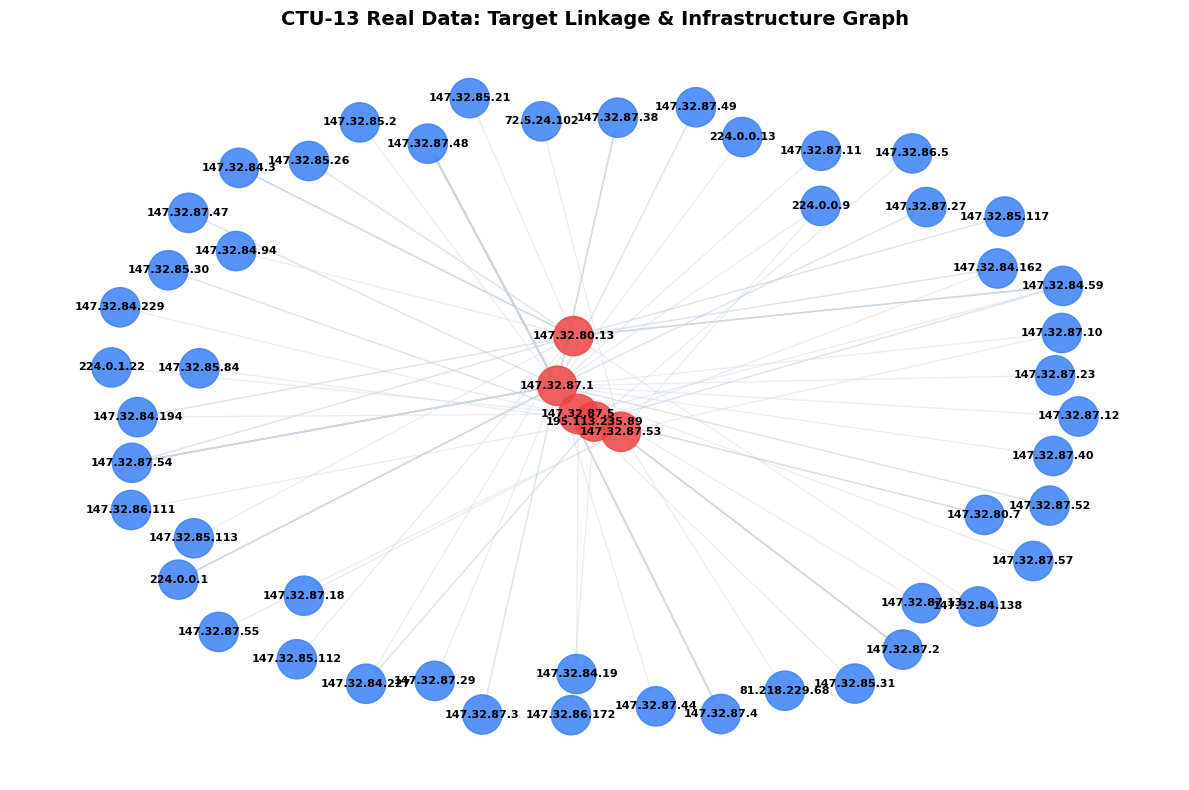

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

G_real = nx.MultiDiGraph()
top_suspect_ips = set(flagged_targets['actor_ip'].head(5))

# Filter original NetFlow data for the identified top suspect IPs
df_suspects = df_real[df_real['SrcAddr'].isin(top_suspect_ips)]

for _, row in df_suspects.iterrows():
    src = row['SrcAddr']
    dst = row['DstAddr']
    port = str(row['Dport'])
    proto = str(row['Proto'])

    # Get risk score for the source actor
    risk = flagged_targets.loc[flagged_targets['actor_ip'] == src, 'target_risk_score'].values[0]

    # Add Nodes
    G_real.add_node(src, type="Suspect_Host", risk=float(risk), color="#ef4444")
    G_real.add_node(dst, type="Target_Endpoint", color="#3b82f6")

    # Add Directed Edge
    G_real.add_edge(src, dst, relationship="COMMUNICATED_WITH", port=port, protocol=proto)

print(f"[+] Built Knowledge Graph: {G_real.number_of_nodes()} Nodes, {G_real.number_of_edges()} Edges")

# Plot the real graph linkage
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_real, k=0.4, seed=42)

node_colors = [data.get("color", "#94a3b8") for _, data in G_real.nodes(data=True)]
nx.draw_networkx_nodes(G_real, pos, node_color=node_colors, node_size=800, alpha=0.85)
nx.draw_networkx_edges(G_real, pos, edge_color="#cbd5e1", alpha=0.4, arrows=True)
nx.draw_networkx_labels(G_real, pos, font_size=8, font_weight="bold")

plt.title("CTU-13 Real Data: Target Linkage & Infrastructure Graph", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()



Real Data: Ingests official .binetflow files directly from the Czech Technical University (CTU-13) repository.

Behavioral Profiling: Groups thousands of raw packet events by IP to calculate port entropy, fan-out ratios, and volumetric anomalies.

Target Identification: The Isolation Forest isolates infected botnet hosts and high-frequency port scanners without manual signatures.

Entity Linkage: The NetworkX graph maps the discovered suspect hosts to their external command-and-control destination endpoints.